## Imports

In [1]:
import os

try:
    from occultence import *
except:
     os.chdir("../..")
    
import occultence
occultence.version()

'0.5.7'

# Run LC all the way through `occultence`

(0.99, 1.015)

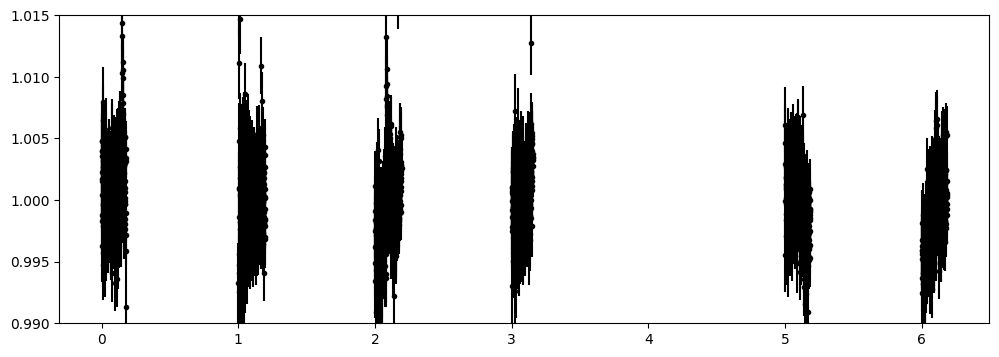

In [2]:
pre_bin = False
file_name = "../../Data/0000000000000000001.csv"
gaia_id = file_name.split("/")[-1].replace(".csv","")

data = pd.read_csv(file_name)

# mask = (~np.isnan(data["diff_flux_use"])) & (~np.isnan(data["diff_error"])) & (data["diff_error"]>0)
# data = data[mask]
# data.reset_index(drop = True, inplace = True)

t = data["bjd"].values - data["bjd"].values[0]
f = data["diff_flux_use"].values
ferr = data["diff_error"].values

# print(f"nr of measurements: {len(t)}")
# if pre_bin:
#     #0.005*24.*60. = 7 minutes
#     #some problem if 7 mins or greater (with smaller_binning, problem with units in astropy)
#     blc = binning(t, f, bins=0.01, error=ferr, std=True)
#     t,f,ferr = blc
#     print(f"nr of measurements after binning: {len(t)}")


# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [3]:
targ = LightCurve(name = "firstLC",
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  metadata={'R_star':0.1*u.R_sun, 'M_star':0.1*u.M_sun})

🤖⚠ Warning! The time array is not an astropy.Time object, therefore there is no info about the 
format or scale.
We will assume that it is JD and TDB from here on! ⚠🤖



In [4]:
targ, targ.bin(dt=0.01*u.d)

(<🌟 Lightcurve firstLC (1912t) 🌟>, <🌟 Lightcurve firstLC_bin (112t) 🌟>)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

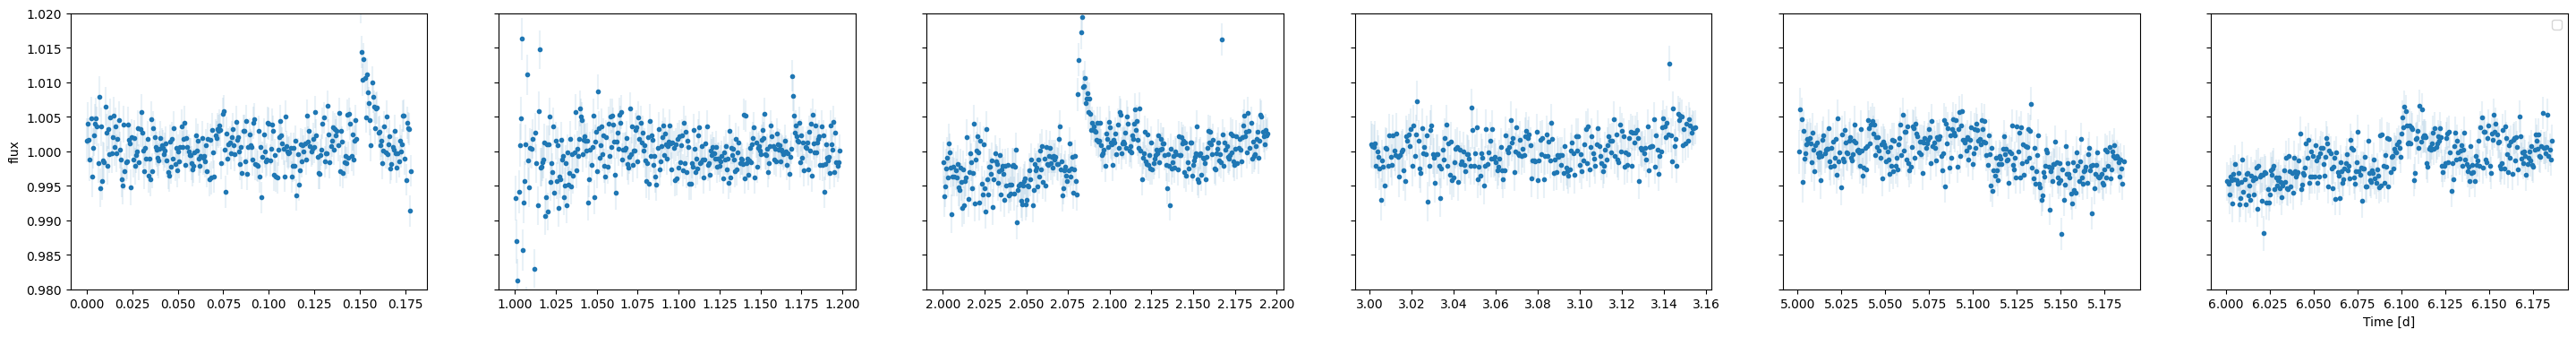

In [5]:
targ.plot()

In [6]:
# planets = targ_with_transit.create_lots_of_transit_params(nfake=100, 
#                                                           minimum_planet_radius=0.5 * u.R_earth, maximum_planet_radius=3 * u.R_earth,
#                                                           minimum_period=0.5 * u.d, maximum_period=1 * u.d,)

In [7]:
targ_with_transit = targ.inject_transit(per=2.55*u.d, 
                                        epoch=0.025 * u.d, 
                                        inc=90 * u.degree, 
                                        rp=1 * u.R_earth, 
                                        ld=[0.3,0.3])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

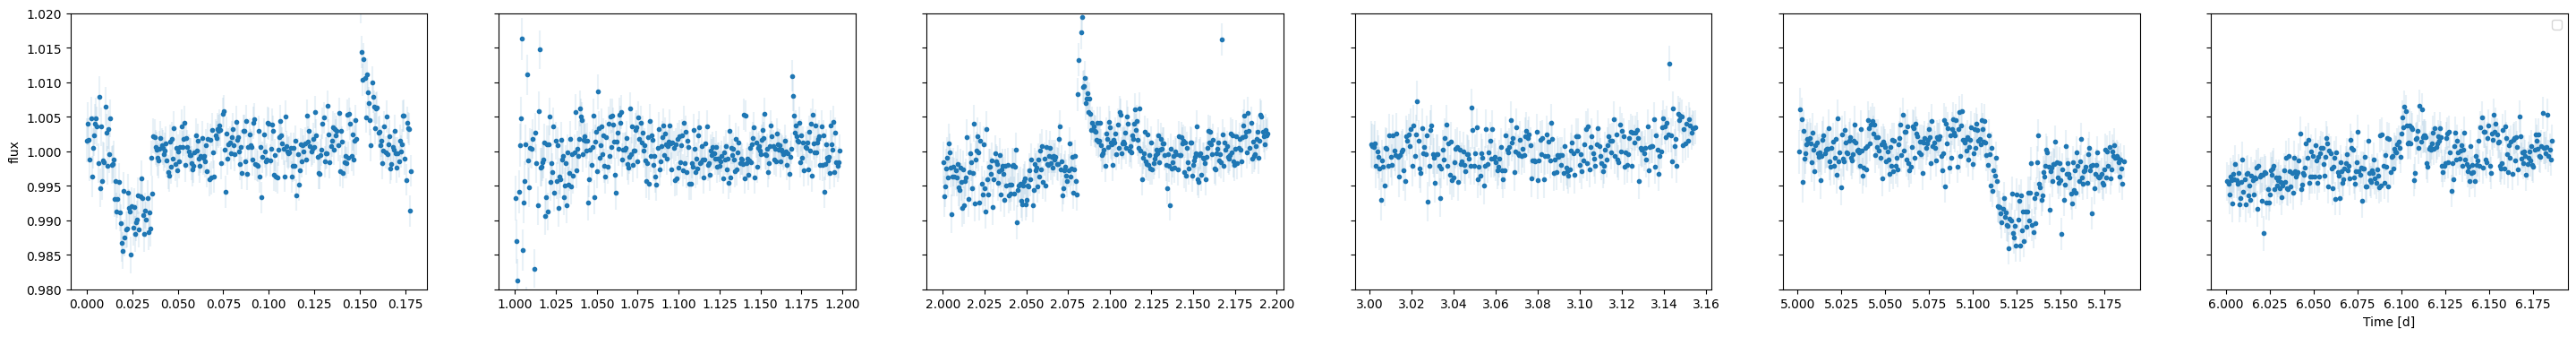

In [8]:
# ax= targ.plot(color='C1')
targ_with_transit.plot(color='C0')

## 1. Normalize each night

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

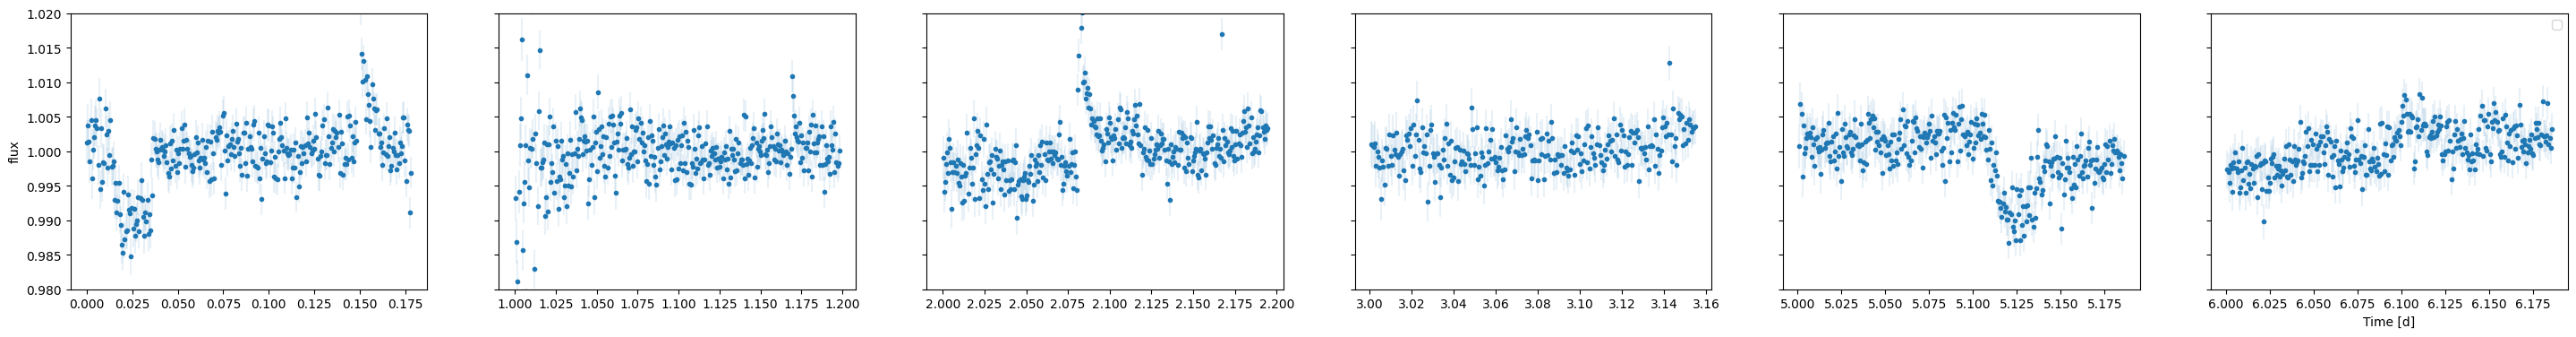

In [9]:
t1 = targ_with_transit.normalize_each_night()
t1.plot()

## 2. Clean

Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...



            0.05230125523012552% of data is flagged as cosmics ⚡.
            


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

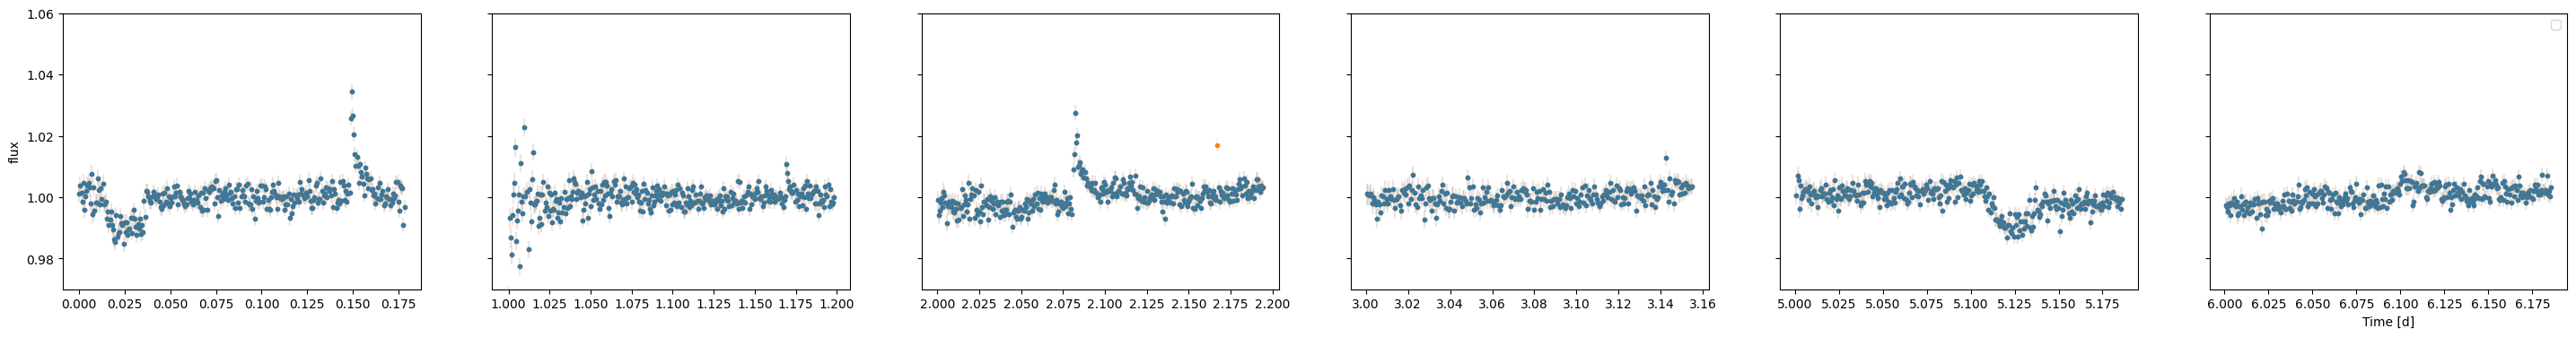

In [10]:
t2 = t1.clean(bad_weather_removal=False, threshold_removal=False, dust_removal=False, verbose=True, cosmic_boxsize=0.01, cosmic_nsigma=5)
ax=t1.plot(color="C1", ylims=[0.97,1.06])
t2.plot(ax=ax, ylims=[0.97,1.06])

## 3. Flares

Don't need to do these steps if we don't care about the rotation:

In [11]:
# t3 = t2.global_and_local_sigma_clip(global_sc_kw={'nsigma_upper':5, 
#                                                              'nsigma_lower':5},
#                                         local_sc_kw={'nsigma_upper':3, 
#                                                      'nsigma_lower':np.inf, 
#                                                      'running_mean_boxsize':0.4}
#                                         )
# t3.plot()

In [12]:
# detrended_targ = t3.lombscargle_detrend(plot=True, ls_binning=30*u.minute,
#                                   minimum_frequency=1/(30*u.d),
#                                   maximum_frequency=1/(0.5*u.d),
#                                   samples_per_peak=10,
#                                   npeaks=1,
#                                   nsigma=3)

Use `.detect_flares_sclip` to find and mask flares:

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 2 flare candidates with >30.0 s over 3$\sigma$
            


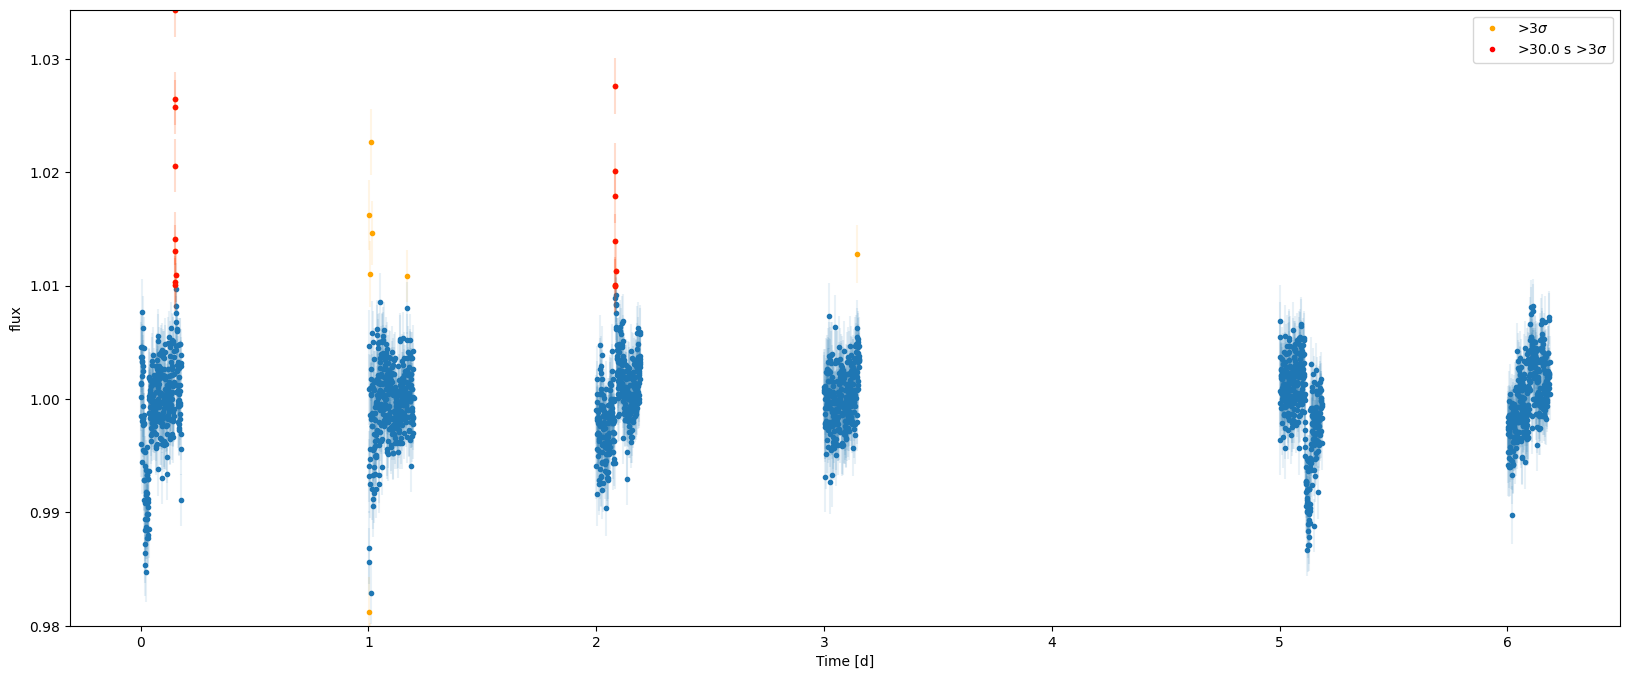

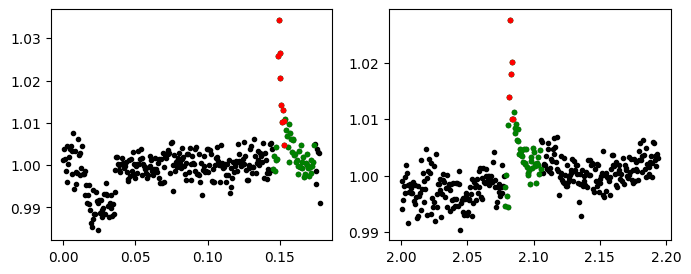

In [13]:
t3 = t2.detect_flares_sclip(plot=True, min_flare_separation=60*u.minute, min_flare_duration=30*u.s, tbuffer_after=30*u.min, 
                                       n_consecutive_points=2, n_points=2,
                                        global_sc_kw={'nsigma_upper': 3, 'nsigma_lower': 5},
                                        local_sc_kw={'nsigma_upper': 3, 'nsigma_lower': np.inf, 'running_median_boxsize': 0.2},)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

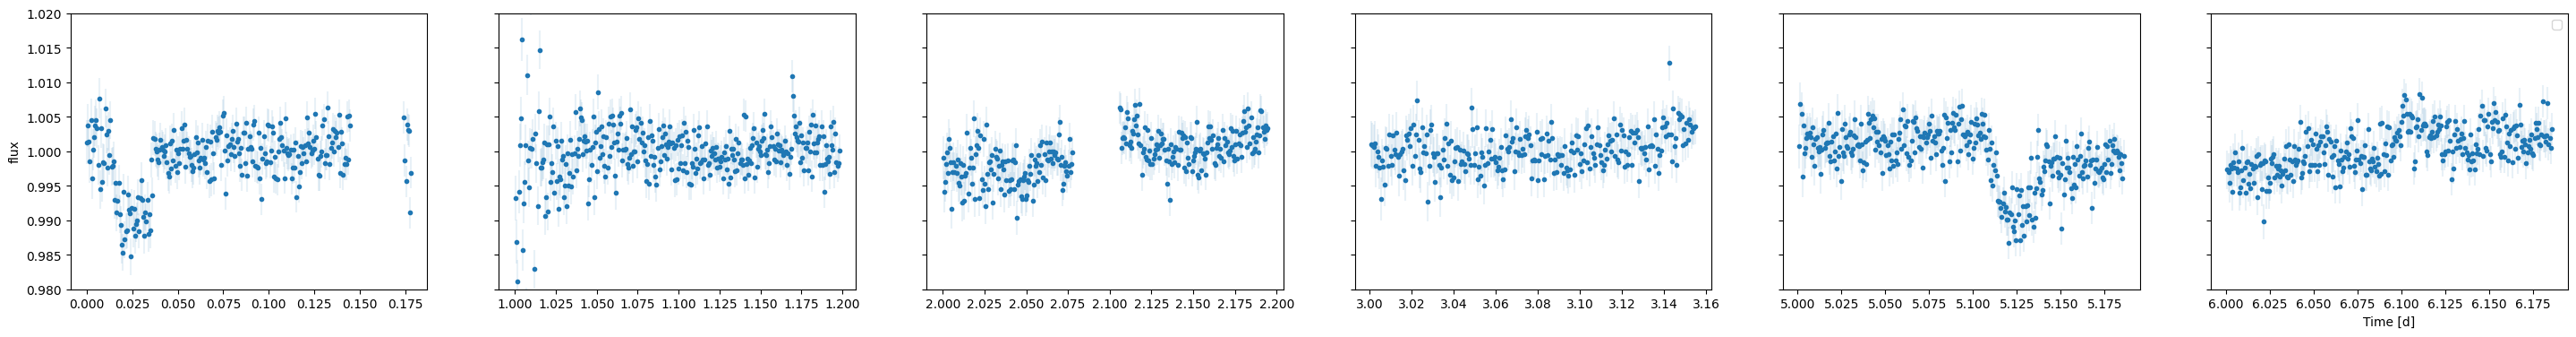

In [14]:
t3.plot()

## 4. Bin and pre-detrend

Bin LC coarsely to GP-detrend.

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

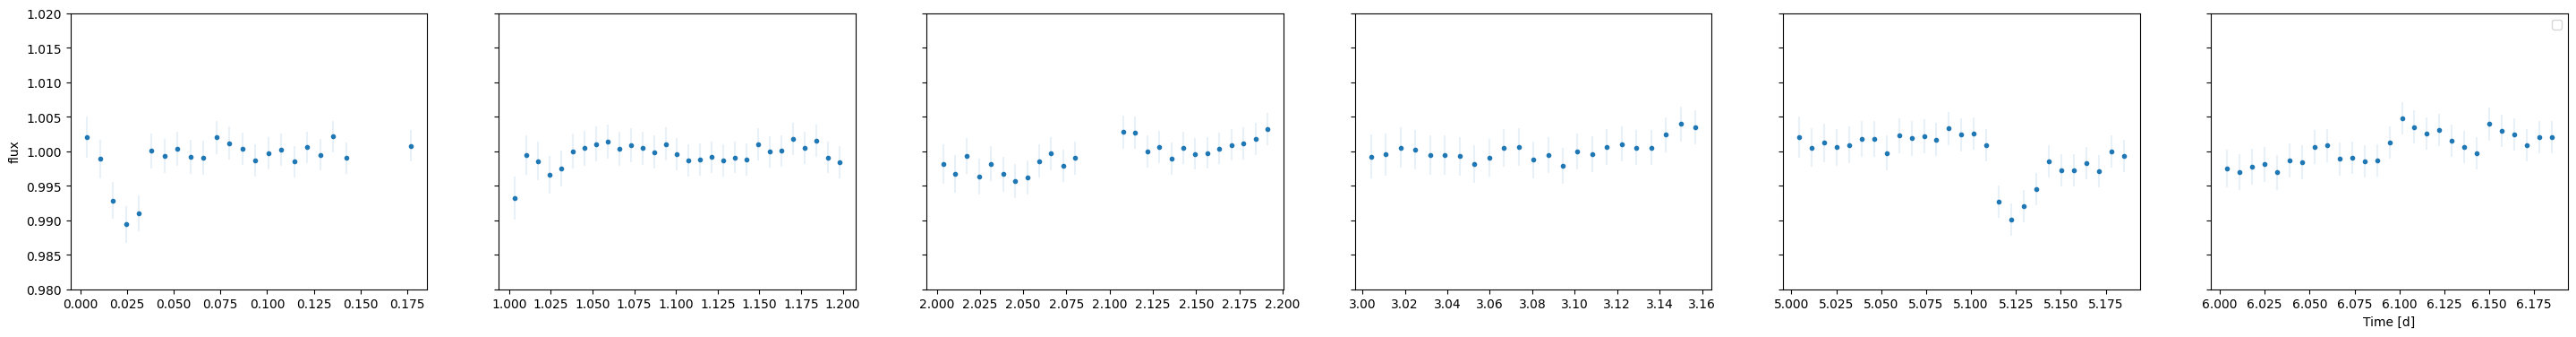

In [15]:
t3_bin = t3.bin(dt = 10*u.min)

t3_bin.telescope = np.array([t3_bin.telescope[0]] * t3_bin.ntime)
t3_bin.filter = np.array([t3_bin.filter[0]] * t3_bin.ntime)

t3_bin.plot()

Perform an initial BLS search to mask transits before running detrending (to avoid over-fitting the transits)

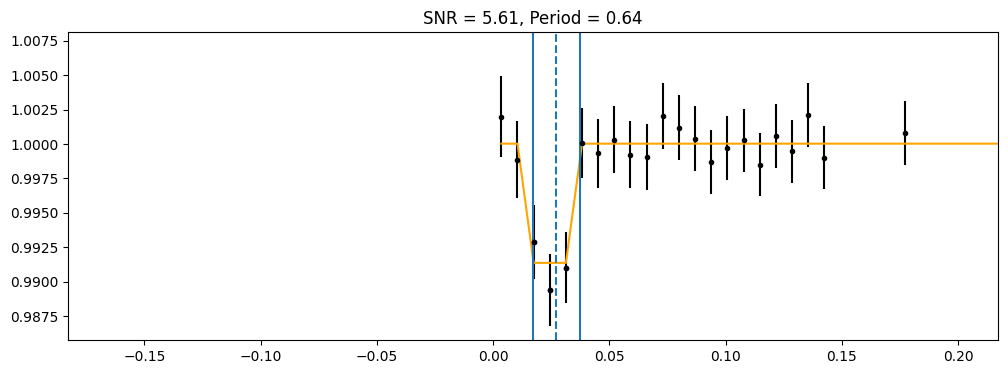

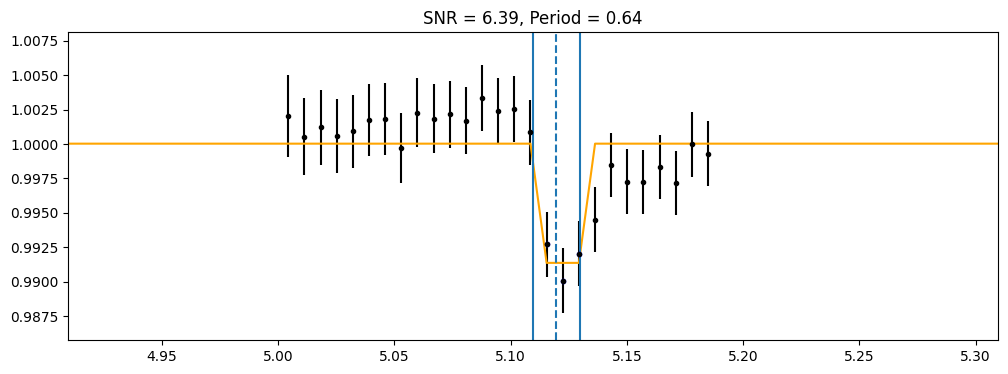

In [16]:
t4 = find_transits(t3_bin, minimum_n_transit=2, transit_durations=[0.01, 0.02, 0.03, 0.04], plot=True, return_all_transits=False, obj="snr", minimum_period=None, maximum_period=None)[0]

In [17]:
t4.metadata

{'name': 'firstLC_inject_normalized_clean_sigmaclipped_flaresremoved_bin_bls_0',
 'target': 'firstLC',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'injected_planet': {'period': [<Quantity 2.55 d>],
  'epoch': [<Quantity 0.025 d>],
  'inc': [<Quantity 90. deg>],
  'rp': [<Quantity 1. earthRad>],
  'a': [<Quantity 3.64584257 solRad>],
  'a_Rs': [<Quantity 36.45842565>],
  'ld': [[0.3, 0.3]],
  'depth': [<Quantity 0.00840502>],
  'duration': [<Quantity 0.02430817 d>]},
 'normalization': [{'norm_og_median': 1.0002498164325095},
  {'norm_og_median': 1.0000377353439704},
  {'norm_og_median': 0.9993019815842068},
  {'norm_og_median': 0.9999339071628168},
  {'norm_og_median': 0.9991873513462306},
  {'norm_og_median': 0.9983136839625296}],
 'thresholds': {},
 'flares_detected': {'nflares': 2,
  'thresholds': {'duration': <Quantity 30. s>,
   'sigma': 3,
   'separation': <Quantity 60. min>},
  'flare_regions': [[257, 308], [795, 843]],
  'flare_frequency': <Quantity 2.1

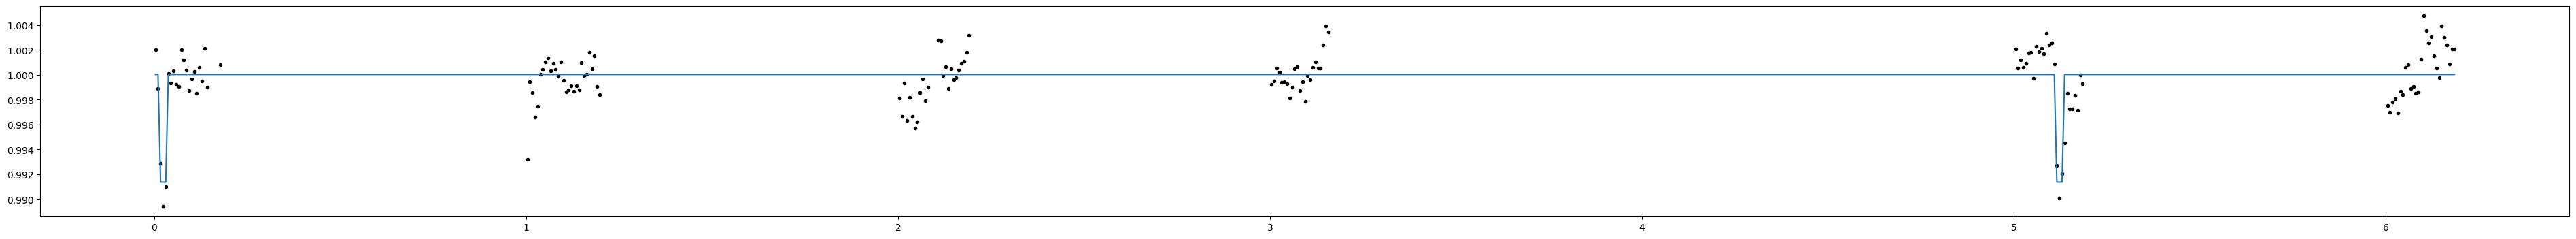

In [18]:
plt.figure(figsize=(48,4))
plt.plot(t3_bin.time.value, t3_bin.flux, 'k.')
plt.plot(t4.time.value, t4.timelike['BLS_model'])

In [19]:
t4

<🌟 Lightcurve firstLC_inject_normalized_clean_sigmaclipped_flaresremoved_bin_bls_0 (160t) 🌟>

Mask transits found

In [20]:
in_transit = t4.metadata['BLS_transits_ind']
t4.masks['transit'] = np.zeros(t4.ntime)
t4.masks['transit'][in_transit] = 1.0
init_transits_masked = t4.clean(zero_flux_removal=False, nan_flux_removal=False,
                                              bad_weather_removal=False, threshold_removal=False,
                                              dust_removal=False, cosmics_removal=False)
t4_mask = init_transits_masked

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

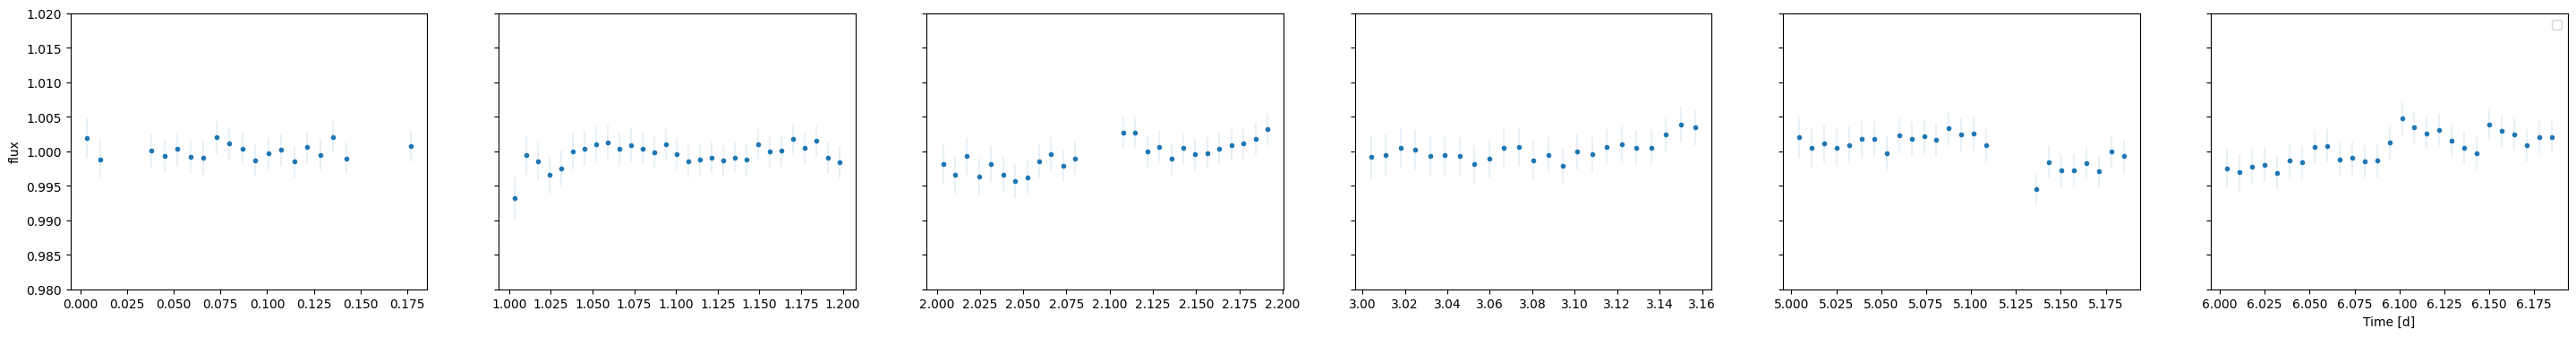

In [21]:
t4_mask.plot()

## 5. GP-detrend

Perform GP-detrending with a Squared-Exponential kernel. Initial hyperparameters may need tuning?

Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-6.03489609 -6.30797415 -2.30258509]
Initial Params: AMP =  0.0018217200291186788 , SQEXP=  0.10000000000000002 , JITTER =  0.0023937452459850007
Initial ln-likelihood: 294.03
Fitted GP HPs: [-27.76182738 -12.87993994  -3.87120101]
Fitted Params: AMP =  2.5486673479304946e-06 , SQEXP=  0.02083333333333333 , JITTER =  8.773877381020333e-13
Final ln-likelihood: 698.85


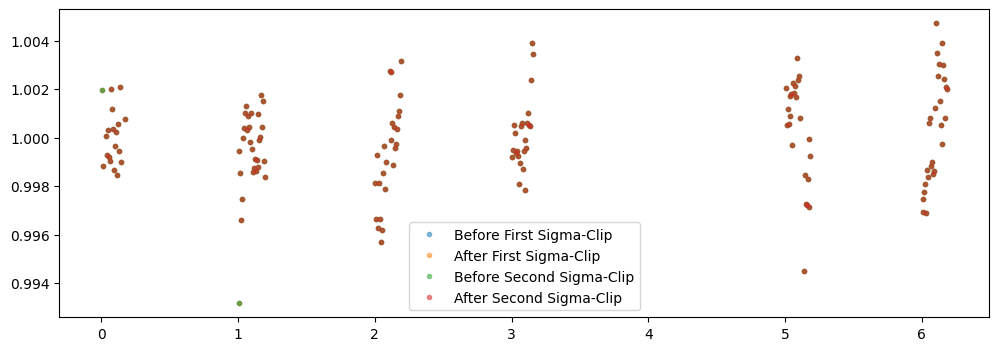

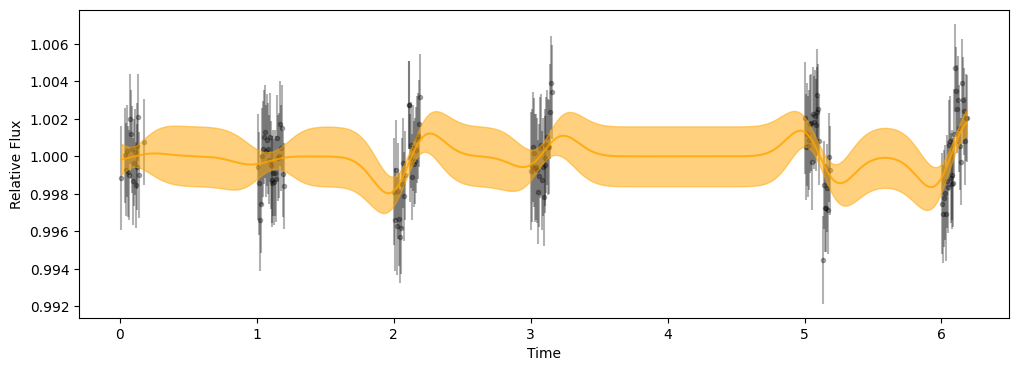

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


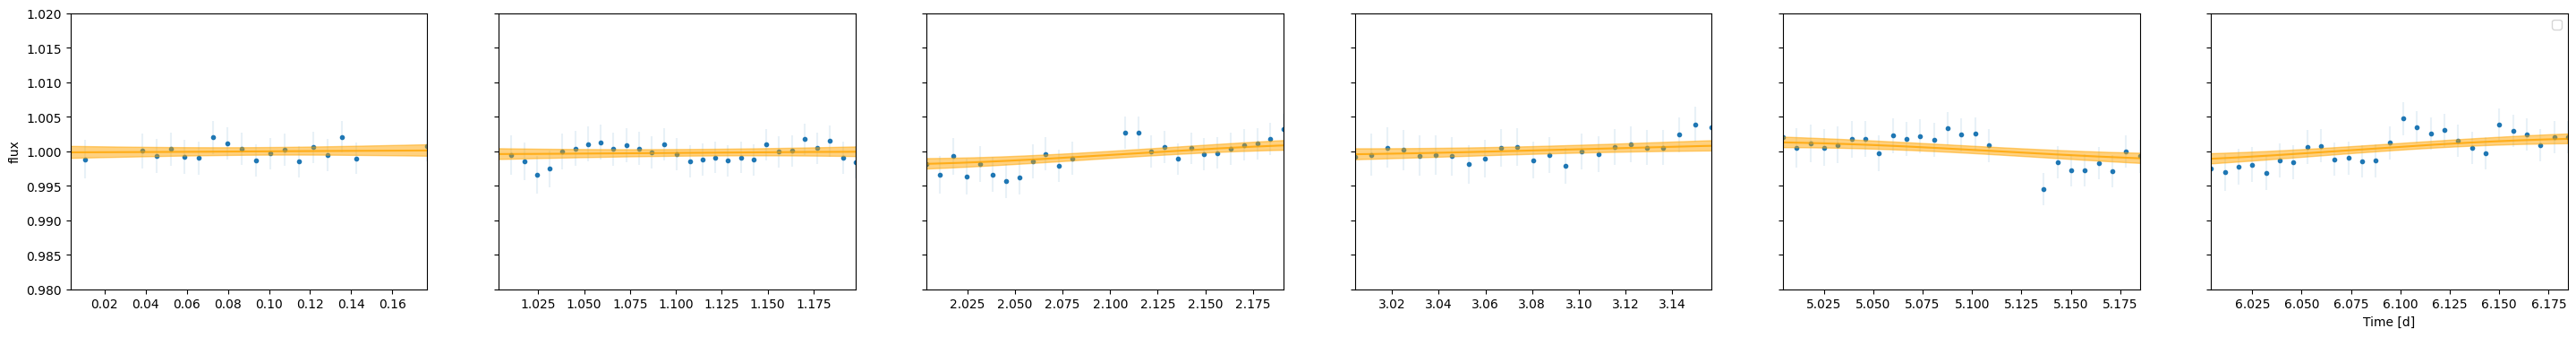

In [22]:
t5 = t4_mask.gp_detrend(use_uncertainties=False, verbose=True, amp_metric=None, sqexp_metric=0.1, sqexp_metric_bound=[np.log((0.5*u.hr).to_value('d')), np.log((np.max(t4_mask.time)-np.min(t4_mask.time)).value)], plot=True)

## 6. BLS again!

In [23]:
# we can also predict the GP for 7.5 min binning and use that for the BLS
bls_bin = 5*u.min
bin_targ = t3.bin(dt=bls_bin)
gp_model = 1 + t5.metadata['gp'].predict(y=t5.metadata['data_to_condition_gp'], t=bin_targ.time.value)[0]
t6 = bin_targ._create_copy()
t6.timelike['flux'] = t6.timelike['flux'] / gp_model

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

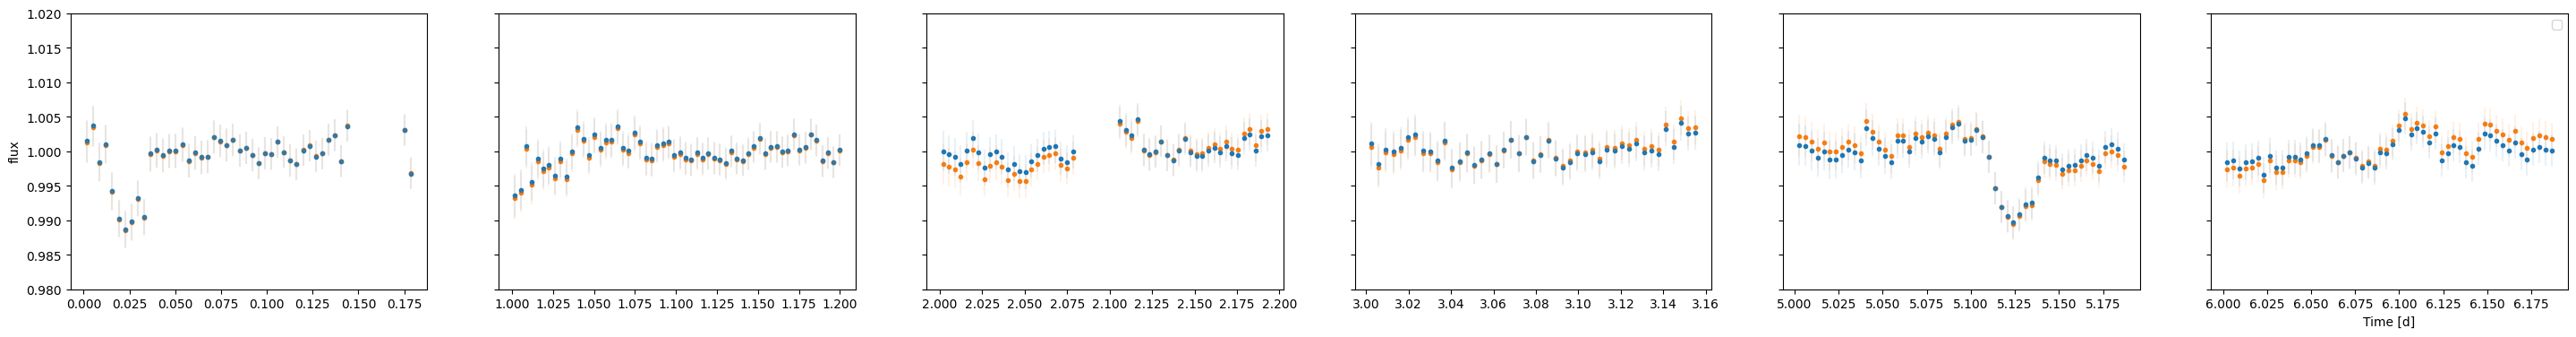

In [24]:
ax=bin_targ.plot(color='C1')
t6.plot(ax=ax)

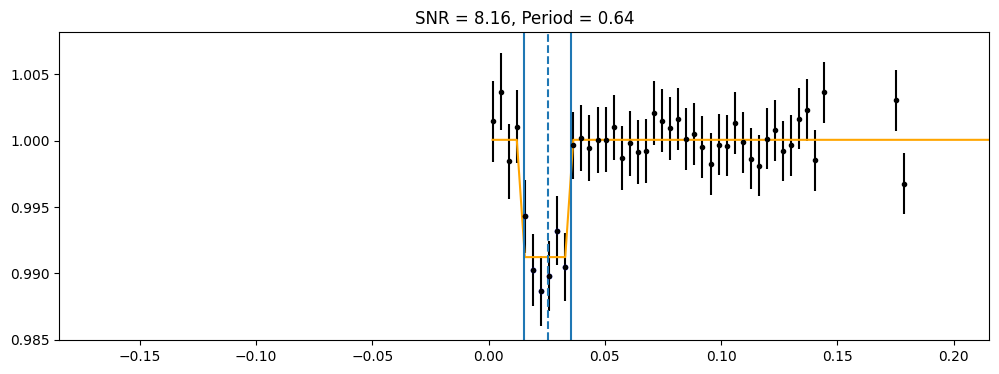

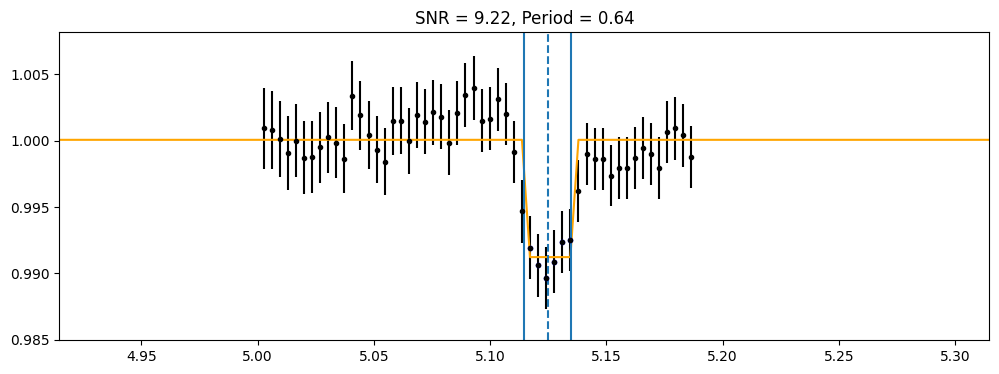

In [25]:
t7 = t6.find_transits(minimum_n_transit=2, transit_durations=[0.01, 0.02, 0.03, 0.04], plot=True, return_all_transits=False, obj="snr", minimum_period=None, maximum_period=None)

In [26]:
t7[0].timelike.keys()

dict_keys(['time', 'time_bin_start', 'time_bin_size', 'flux', 'uncertainty', 'original_time_index', 'transit_model', 'BLS_model'])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

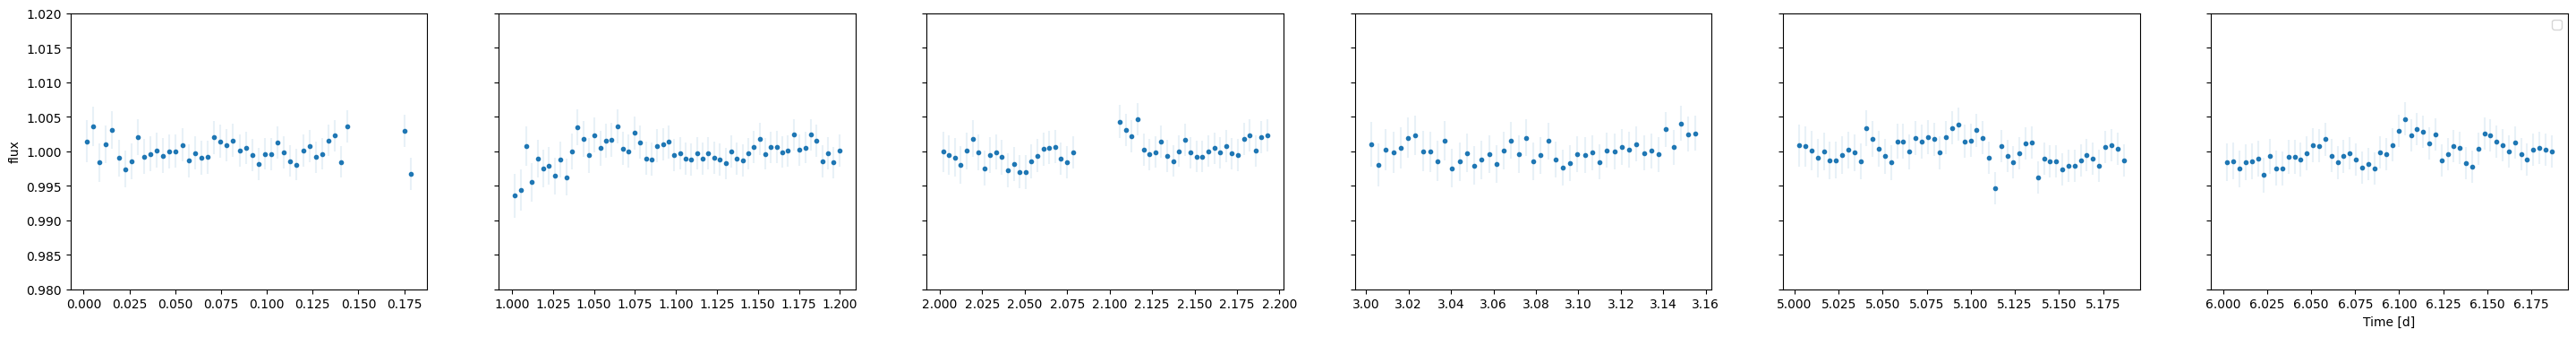

In [27]:
t7[0].plot()

In [28]:
t7[0].find_transits(minimum_n_transit=2, transit_durations=[0.01, 0.02, 0.03, 0.04], plot=True, return_all_transits=False, obj="snr", minimum_period=None, maximum_period=None)

[]

In [46]:
per=2.55*u.d
epoch=0.025 * u.d
inc=90 * u.degree
rp=1 * u.R_earth
ld=[0.3,0.3]

In [47]:
def create_planet(self, per, epoch, inc, rp, ld, M=None, R=None, i=None):
    if R is None or M is None:
        if "R_star" in self.metadata and "M_star" in self.metadata:
            R = self.metadata['R_star']
            M = self.metadata['M_star']
        else:
            warnings.warn("To generate a planet distribution for this star, we need its radius and mass. Please store"
                          "the radius and mass in the .metadata dict or pass them explicitly to this function!")
            return

    model = pytransit_model(time=self.time.value, Rp=rp, ldc=ld, t0=epoch-(self.time.value[0]*u.d), p=per, R=R, M=M,
                            i=inc)

    a_Rs = semi_major_axis(per, M, R).decompose()
    b = a_Rs * math.cos(inc.to_value('radian'))
    sini = math.sin(inc.to_value('radian'))
    k = (rp / R).decompose()
    transit_depth = k ** 2
    transit_duration = (per / math.pi) * math.asin((1 / a_Rs) * np.sqrt((1 + k) ** 2 - b ** 2) / sini)

    return {'a_Rs':a_Rs, 'b':b, 'sini':sini, 'k':k, 'transit_depth':transit_depth, 'transit_duration':transit_duration}

In [49]:
pp = create_planet(targ, per, epoch, inc, rp, ld)
planets = pd.DataFrame({'logP': np.log10(per), #'phase': params[1], 
                        'cosi': pp['b']/pp['a_Rs'], 'r_p': params[2],
                                'depth': transit_depth, 'duration': transit_duration,
                                'epoch': transit_epoch, 'a':transit_a, 'a_Rs':transit_a_Rs,
                                'injected':np.zeros(len(params[0])),
                                'recovered': np.zeros(len(params[0])), 'observed': np.zeros(len(params[0])),
                                'log_Prec': np.zeros(len(params[0])), 'rec_depth': np.zeros(len(params[0])),
                                'rec_duration': np.zeros(len(params[0])), 'rec_epoch': np.zeros(len(params[0])),
                                'run': np.zeros(len(params[0])), 'snr': np.zeros(len(params[0])),
                                'target': [self.name] * len(params[0]), 'r_s': [R_star] * len(params[0]),
                                'm_s': [M_star] * len(params[0]), 'teff': [T_eff] * len(params[0]),
                                'spt': [SpT] * len(params[0])})

{'a_Rs': <Quantity 36.45842565>,
 'b': <Quantity 2.23243471e-15>,
 'sini': 1.0,
 'k': <Quantity 0.09167888>,
 'transit_depth': <Quantity 0.00840502>,
 'transit_duration': <Quantity 0.02430817 d>}

In [34]:
planets = targ_with_transit.create_lots_of_transit_params(nfake=1, 
                                                          minimum_planet_radius=0.5 * u.R_earth, maximum_planet_radius=3 * u.R_earth,
                                                          minimum_period=0.5 * u.d, maximum_period=1 * u.d,)
planets

,logP,phase,cosi,r_p,depth,duration,epoch,a,a_Rs,injected,...,rec_depth,rec_duration,rec_epoch,run,snr,target,r_s,m_s,teff,spt
0,-0.061771,0.111889,0.00215,1.048028,0.009231755672389489,0.017035,0.097055,1.7766040158586436 solRad,17.766040158586435,0.0,...,0.0,0.0,0.0,0.0,0.0,firstLC_inject,0.1 solRad,0.1 solMass,None,None


1/1...


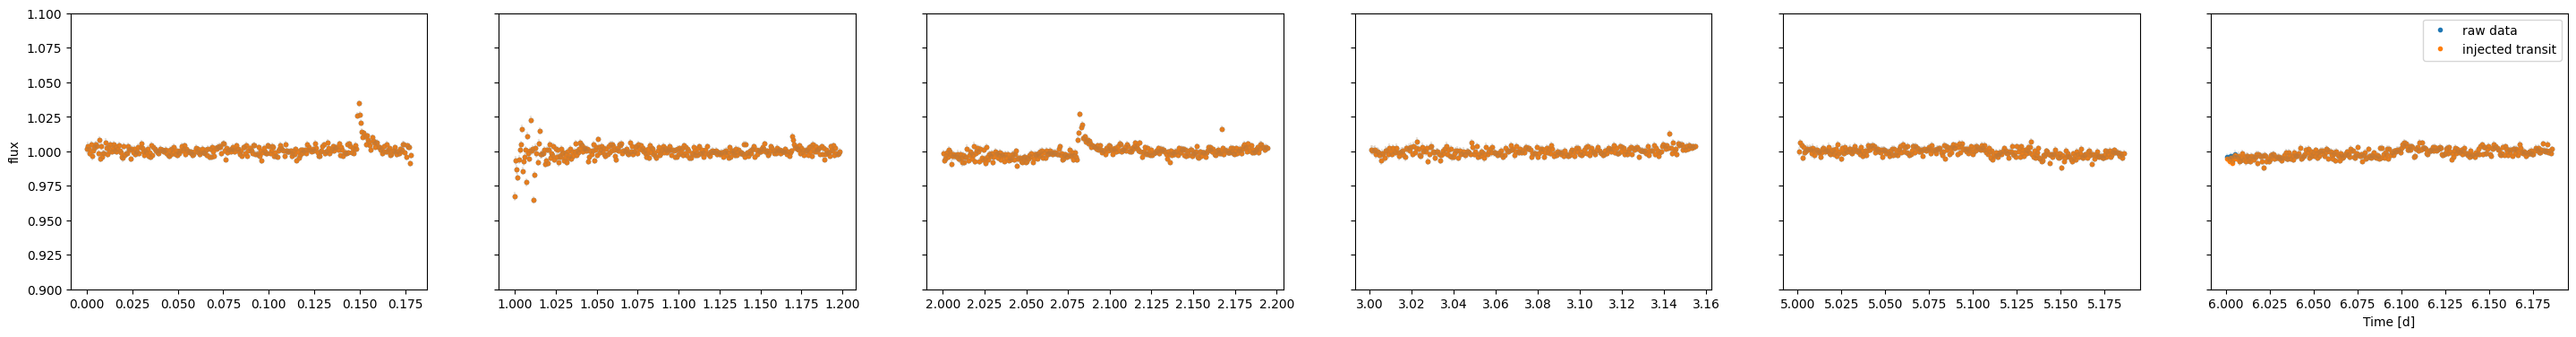

Time to clean LC: 0.6121170520782471
Time to BLS before detrending: 0.6661429405212402


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Time to detrend: 0.6149008274078369


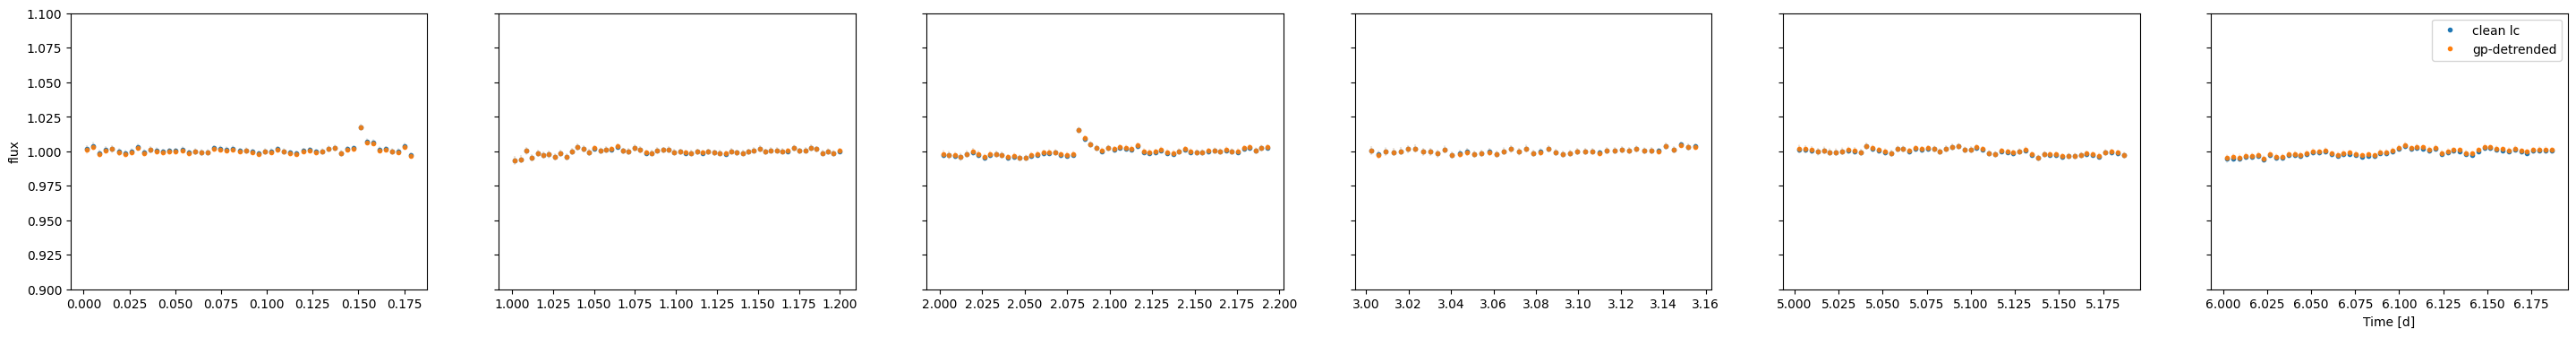

Time to BLS search: 0.7263758182525635
Time to inject-recover 1 planets: 4.443846940994263
Planets recovered: 100.0%
But not all of those planets transited during the observation window...
None of the planets injected were observed!


In [31]:
x = targ.full_injection_recovery(lcs_with_transits=[targ_with_transit],
                                 planets=,
                                 nfake=1,
                                 minimum_planet_radius=0.25 * u.R_earth, 
                                 maximum_planet_radius=1 * u.R_earth,
                                 minimum_period=0.5 * u.d, 
                                 maximum_period=2 * u.d, 
                                 ld=[0.3,0.3],
                                 clean_kw = {'dust_removal': False, 'bad_weather_removal': False,'cosmics_removal': True, 'cosmic_boxsize':0.01, 'cosmic_nsigma':5},
                                 detrend_method = "gp", 
                                 detrend_bin = 20 * u.minute,
                                 detrend_kw = {'do_first_sigma_clip': True, 'do_second_sigma_clip': True,
                                               'running_median_boxsize': 0.08, 'nsigma': 3, 'plot': False,
                                               'use_uncertainties':False, 'amp_metric':None, 'sqexp_metric':0.1, 
                                               'sqexp_metric_bound':[np.log((0.5*u.hr).to_value('d')), np.log((np.max(t4_mask.time)-np.min(t4_mask.time)).value)]},
                                bls_kw = {"minimum_period":None, "maximum_period":None, 'minimum_n_transit':2, 'obj':'snr',
                                      'transit_durations':[0.01,0.02,0.03,0.04], 'plot':False, 'verbose': False}, 
                                bls_bin=5 * u.minute,
                                recovery_kw = {'condition_on_epoch':1 * u.hour, 'min_n_transits': 1, 'meet_condition': 'any'},                           
                                verbose=False, plot=True, time_this_process=True)

In [ ]:
lcs, lcs_clean, lcs_gp, lcs_bls, planets_df = x

In [ ]:
def full_injection_recovery(self,
                            nfake=10,
                            pool_bls=False,
                            poolkw={'chunksize':1},
                            ncores=4,
                            minimum_planet_radius=0.5 * u.R_earth,
                            maximum_planet_radius=3 * u.R_earth,
                            minimum_period=0.5 * u.d,
                            maximum_period=10 * u.d,
                            ld=[0.385, 0.304],
                            clean_kw = {'dust_removal': False, 'bad_weather_removal': False, 'cosmics_removal': True,
                                        'cosmic_boxsize': 0.08, 'cosmic_nsigma': 3},
                            detrend_method = "gp",
                            detrend_bin = 20 * u.minute,
                            detrend_kw = {'do_first_sigma_clip': True, 'do_second_sigma_clip': True,
                                     'running_mean_boxsize': 0.08, 'nsigma': 3, 'plot': False},
                            bls_kw = {"minimum_period":0.5, "maximum_period":10,
                                      'transit_durations':np.linspace(0.01, 0.1, 4), 'plot':False, 'verbose': False},
                            bls_bin=7.5 * u.minute,
                            recovery_kw = {'condition_on_epoch': 1 * u.hour, 'min_n_transits': 1,
                                           'meet_condition': 'any'},
                            plot=False,
                            verbose=False,
                            time_this_process=False,
                            svname="injected_planets.csv",
                            planets=None,
                            lcs_with_transits=None,
                            ):

    if planets is None or lcs_with_transits is None:
        lcs_with_transits, planets = self.inject_lots_of_transits(nfake=nfake,
                                                                  minimum_planet_radius=minimum_planet_radius,
                                                                  maximum_planet_radius=maximum_planet_radius,
                                                                  minimum_period=minimum_period,
                                                                  maximum_period=maximum_period,
                                                                  ld=ld,
                                                                  fname=svname)

    bls_kw['verbose'] = verbose
    clean_lcs, bin_lcs, detrend_lcs, bls_lcs = [],[],[],[]

    if time_this_process:
        t0 = time.time()

    planets = pd.read_csv(svname)

    if pool_bls:
        import occultence.recovery.single_inj_rec as sir
        print(f"Pooling {nfake} injection-recoveries with {ncores} cores and kw={poolkw}.")
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            # results = pool.starmap(sir.single_injection_recovery,
            #                        [(self, lc, planets, i, clean_kw, detrend_bin, detrend_kw, bls_kw, bls_bin,
            #                          recovery_kw, detrend_method, time_this_process) for i, lc in enumerate(lcs_with_transits)],
            #                        **poolkw)

            for i, lc in enumerate(lcs_with_transits):
                planets.loc[i, 'injected'] = 1.0
                planets.loc[i, 'observed'] = int(lc.was_planet_observed())

                clean_targ, bin_targ = self.single_clean_bin(lc, clean_kw, detrend_bin)
                removed_nans = bin_targ.remove_nans()
                bin_lcs.append(removed_nans)
                clean_lcs.append(clean_targ)

            # pool the pre-detrend BLS
            pool = Pool(ncores)
            bin_lcs_pre = pool.starmap(sir.single_predetrend, [(lc, bls_kw) for lc in bin_lcs])

            # for now I cannot pool the GP-detrending - I believe it's an issue with george or NaNs
            for bin_lc, clean_lc, orig_bin_lc in zip(bin_lcs_pre, clean_lcs, bin_lcs):
                detrend_lc = bin_lc.single_detrend(clean_targ=clean_lc, orig_bin_targ=orig_bin_lc, detrend_kw=detrend_kw,
                                            detrend_method=detrend_method, bls_bin=bls_bin, )
                detrend_lcs.append(detrend_lc)

            # pool the post-detrend BLS
            pool = Pool(ncores)
            results = pool.starmap(sir.single_bls, [(i, lc, bls_kw, recovery_kw, planets,
                                                     time_this_process, verbose) for i, lc in enumerate(detrend_lcs)])

            bls_lcs = [r[0] for r in results]
            planets_list = [r[1] for r in results]

        for i, p in enumerate(planets_list):
            planets.loc[i] = p.iloc[i]

        planets.to_csv(svname, index=False)

    else:
        for i, lc in enumerate(lcs_with_transits):
            try:
                print(f"{i+1}/{len(lcs_with_transits)}...")
                planets.loc[i, 'injected'] = 1.0
                planets.loc[i, 'observed'] = int(lc.was_planet_observed())
                clean_targ, detrend_targ, bls_targ, planets = self.single_injection_recovery(lc=lc,
                                                                                            planets=planets,
                                                                                            i=i,
                                                                                            clean_kw=clean_kw,
                                                                                            detrend_method=detrend_method,
                                                                                            detrend_bin=detrend_bin,
                                                                                            detrend_kw=detrend_kw,
                                                                                            bls_kw=bls_kw,
                                                                                            bls_bin=bls_bin,
                                                                                            recovery_kw=recovery_kw,
                                                                                            plot=plot,
                                                                                            time_this_process=time_this_process,
                                                                                            verbose=verbose)
                planets.to_csv(svname, index=False)
                clean_lcs.append(clean_targ)
                detrend_lcs.append(detrend_targ)
                bls_lcs.append(bls_targ)
            except Exception as e:
                print(e)

    if time_this_process:
        t1 = time.time()
        print(f"Time to inject-recover {nfake} planets: {t1-t0}")

    # print summary
    print(f"Planets recovered: {100 * len(planets.loc[planets['recovered'] == 1.0]) / len(planets['recovered'])}%")
    print("But not all of those planets transited during the observation window...")
    if len(planets['recovered'][planets['observed'] == 1.0]) > 0:
        print(f"""Observed Planets recovered: {(100 * len(planets.loc[(planets['recovered'] == 1.0) &
                (planets['observed'] == 1.0)]) / len(planets['recovered'][planets['observed'] == 1.0])):.1f}%""")
    else:
        print("None of the planets injected were observed!")

    return lcs_with_transits, clean_lcs, detrend_lcs, bls_lcs, planets